# Clustering Evaluation - 5-Fold Cross-Validation

Evaluates the cluster-based adaptive resolution strategies with stratified 5-fold
cross-validation over the **full** benchmark, instead of the single 80/20 split used by
`clustering_inference.ipynb`.

Per fold: KMeans (K fixed at 30) and the cluster→resolution mapping are fitted on the
training folds only, then applied to the held-out fold. Every question is therefore
evaluated exactly once, out-of-fold. Reported numbers are the mean (± std) across folds.

Per-cluster reporting is intentionally omitted: cluster IDs are arbitrary and not
comparable across folds. The deliverables are the strategy comparison table and the
accuracy vs. computational cost graph.

**Inputs**: dataset (`.jsonl`), ground-truth scores (`.xlsx`) - no trained artifacts needed; each fold fits its own model
**Outputs**: per-fold and aggregated strategy metrics (`.csv`), accuracy vs. cost graph (`.pdf`)

In [1]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer


---
## 0 · Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATASET      = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/test_questions.jsonl')
SCORES_FILE  = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/qwen3_resolution_analysis.xlsx')
#SCORES_FILE  = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/seedbench_2_plus_resolution_analysis.xlsx')
SCORES_SHEET = 'Consolidated_Scores'

# ── Resolution tokens (must match training) ──────────────────────────────────
RESOLUTIONS = ['2000', '12500', '25000', '50000', '100000',
               '150000', '250000', '400000', '600000', '800000']

# ── Cross-validation setup ───────────────────────────────────────────────────
N_FOLDS      = 5
N_CLUSTERS   = 30          # K fixed at the shipped value; no per-fold silhouette sweep
RANDOM_STATE = 42
STRATIFY_BY  = 'subject'   # keeps the Chart/Map/Web mix identical in every fold

# ── Embedding model (must match training) ────────────────────────────────────
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# ── Outputs ──────────────────────────────────────────────────────────────────
FOLD_METRICS_OUTPUT = str(PROJECT_ROOT / 'clustering/inference/results/qwen3/k_fold_metrics.csv')
SUMMARY_OUTPUT      = str(PROJECT_ROOT / 'clustering/inference/results/qwen3/k_fold_strategy_comparison.csv')
GRAPH_PDF           = str(PROJECT_ROOT / 'clustering/inference/results/qwen3/k_fold_final_graph.pdf')

---
## 1 · Load & preprocess the full dataset

In [3]:
import json, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sentence_transformers import SentenceTransformer

sns.set_style('whitegrid')
%matplotlib inline

# ── Load questions ────────────────────────────────────────────────────────────
with open(DATASET, 'r', encoding='utf-8') as f:
    df = pd.DataFrame([json.loads(line) for line in f])

# ── Merge ground-truth scores per resolution ──────────────────────────────────
df_scores = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
df = df.merge(df_scores[['doc_id'] + RESOLUTIONS], on='doc_id', how='left')

# ── Clean question text (same transform as training) ──────────────────────────
def clean_input(text: str) -> str:
    text = text.replace("Answer with the option's letter from the given choices directly.", '').strip()
    match = re.search(r'\n[A-D]\.\s', text)
    return text[:match.start()].strip() if match else text

df['question_stem'] = df['input'].apply(clean_input)

# ── Benchmark subject (Chart / Map / Web) for stratification ──────────────────
subject_cols = [c for c in df.columns
                if c.startswith('seedbench_2_plus_') and c != 'seedbench_2_plus_all']
df['subject'] = (df[subject_cols].notna().idxmax(axis=1)
                 .str.replace('seedbench_2_plus_', '', regex=False))

print(f"Loaded {len(df)} questions with {len(RESOLUTIONS)} resolutions")
print(df['subject'].value_counts().to_string())

/home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2277 questions with 10 resolutions
subject
Chart    810
Map      807
Web      660


---
## 2 · Embeddings

Computed once for the whole dataset: embeddings are deterministic and fold-independent,
so only the KMeans fit and the resolution mapping need to be per-fold.

In [4]:
encoder = SentenceTransformer(EMBEDDING_MODEL)
embeddings = encoder.encode(df['question_stem'].tolist(), show_progress_bar=True)
print(f'Embeddings: {embeddings.shape}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2255.14it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 72/72 [00:00<00:00, 169.76it/s]

Embeddings: (2277, 384)


---
## 3 · Cross-validation loop

For each fold: fit KMeans on the training folds, derive the cluster→resolution mapping
from those rows only (same rules as the training notebook: best, and the cheapest
resolution reaching 95% / 99% of the best accuracy), then predict clusters for the
held-out fold and score every strategy on it.

In [5]:
S  = df[RESOLUTIONS].values.astype(float)          # (n, 10) binary correctness
RV = np.array([int(r) for r in RESOLUTIONS])
MAX_RES = RV.max()

STRATEGIES = [('Best per cluster', 'best'), ('Efficient (95%)', 'eff95'), ('Efficient (99%)', 'eff99')]


def derive_mapping(scores_sub, labels_sub, k):
    """cluster -> resolution index per strategy, from training rows only."""
    mapping = {name: np.zeros(k, int) for _, name in STRATEGIES}
    for c in range(k):
        m = labels_sub == c
        if not m.any():                                # empty cluster: fall back to max resolution
            for v in mapping.values():
                v[c] = len(RESOLUTIONS) - 1
            continue
        acc = scores_sub[m].mean(axis=0)
        b = int(acc.argmax())
        mapping['best'][c] = b
        for name, frac in (('eff95', 0.95), ('eff99', 0.99)):
            hit = np.flatnonzero(acc >= acc[b] * frac)   # RESOLUTIONS ascending: first hit is cheapest
            mapping[name][c] = int(hit[0]) if len(hit) else b
    return mapping


skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []

for fold, (tr_i, va_i) in enumerate(skf.split(embeddings, df[STRATIFY_BY])):
    km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(embeddings[tr_i])
    mapping = derive_mapping(S[tr_i], km.labels_, N_CLUSTERS)
    pred = km.predict(embeddings[va_i])

    # Fixed-resolution baselines on the held-out fold
    for j, res in enumerate(RESOLUTIONS):
        fold_rows.append({'fold': fold, 'strategy': f'Fixed {res}',
                          'accuracy': S[va_i, j].mean(),
                          'cost_pct': RV[j] / MAX_RES * 100})

    # Cluster-based strategies on the held-out fold
    for label, name in STRATEGIES:
        res_idx = mapping[name][pred]
        fold_rows.append({'fold': fold, 'strategy': label,
                          'accuracy': S[va_i, res_idx].mean(),
                          'cost_pct': RV[res_idx].mean() / MAX_RES * 100})

    print(f'fold {fold}: {len(va_i)} held-out questions scored')

df_folds = pd.DataFrame(fold_rows)
os.makedirs(os.path.dirname(FOLD_METRICS_OUTPUT), exist_ok=True)
df_folds.to_csv(FOLD_METRICS_OUTPUT, index=False)
print(f'\nPer-fold metrics saved to {FOLD_METRICS_OUTPUT}')

fold 0: 456 held-out questions scored
fold 1: 456 held-out questions scored
fold 2: 455 held-out questions scored
fold 3: 455 held-out questions scored
fold 4: 455 held-out questions scored

Per-fold metrics saved to /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/clustering/inference/results/qwen3/k_fold_metrics.csv


---
## 4 · Strategy comparison table

Mean and standard deviation across the folds. Fixed-resolution costs are deterministic
(std = 0 by construction); cluster-strategy costs vary because each fold learns its own
mapping.

In [6]:
STRATEGY_ORDER = [f'Fixed {r}' for r in RESOLUTIONS] + [label for label, _ in STRATEGIES]

df_summary = (df_folds.groupby('strategy')
              .agg(accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
                   cost_pct_mean=('cost_pct', 'mean'), cost_pct_std=('cost_pct', 'std'))
              .reindex(STRATEGY_ORDER)
              .reset_index())

df_summary.to_csv(SUMMARY_OUTPUT, index=False)
print(f'Summary saved to {SUMMARY_OUTPUT}\n')
print(f'STRATEGY COMPARISON ({N_FOLDS}-fold cross-validation, mean ± std across folds)')
print('=' * 70)
display(df_summary.round(4))

Summary saved to /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/clustering/inference/results/qwen3/k_fold_strategy_comparison.csv

STRATEGY COMPARISON (5-fold cross-validation, mean ± std across folds)


,strategy,accuracy_mean,accuracy_std,cost_pct_mean,cost_pct_std
0,Fixed 2000,0.4704,0.0256,0.2500,0.0000
1,Fixed 12500,0.4752,0.0239,1.5625,0.0000
2,Fixed 25000,0.4923,0.0183,3.1250,0.0000
3,Fixed 50000,0.5279,0.0127,6.2500,0.0000
4,Fixed 100000,0.5951,0.0120,12.5000,0.0000
5,Fixed 150000,0.6342,0.0244,18.7500,0.0000
6,Fixed 250000,0.6794,0.0100,31.2500,0.0000
7,Fixed 400000,0.6935,0.0087,50.0000,0.0000
8,Fixed 600000,0.7062,0.0104,75.0000,0.0000
9,Fixed 800000,0.7123,0.0167,100.0000,0.0000


---
## 5 · Accuracy vs. computational cost graph

Points are fold means; error bars are ± 1 std across folds. Every number is out-of-fold:
computed on questions excluded from both the KMeans fit and the resolution selection of
the fold that scored them.

Graph saved to /home/das/poli/redes-neurais-e-dl/scale-wise-optimizer/clustering/inference/results/qwen3/k_fold_final_graph.pdf


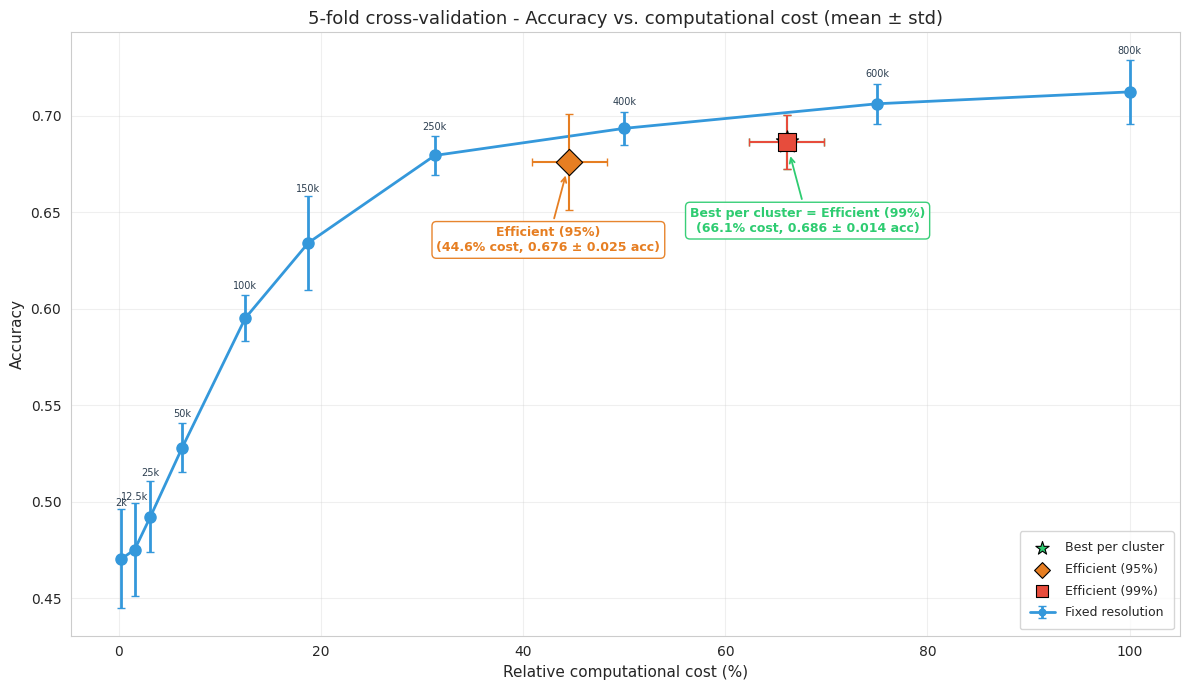

In [7]:
SHORT_RES = {'2000': '2k', '12500': '12.5k', '25000': '25k', '50000': '50k',
             '100000': '100k', '150000': '150k', '250000': '250k',
             '400000': '400k', '600000': '600k', '800000': '800k'}

fig, ax = plt.subplots(figsize=(12, 7))

# ── Fixed-resolution curve ────────────────────────────────────────────────────
df_fixed = df_summary[df_summary['strategy'].str.startswith('Fixed')]
ax.errorbar(df_fixed['cost_pct_mean'], df_fixed['accuracy_mean'],
            yerr=df_fixed['accuracy_std'],
            fmt='o-', color='#3498db', lw=2, ms=8, capsize=3,
            label='Fixed resolution', zorder=3)

# Labels sit just past the error bar so label and bar never collide
y0, y1 = ax.get_ylim()
ax_h_pts = fig.get_size_inches()[1] * 72 * 0.78
for _, r in df_fixed.iterrows():
    err_pts = r['accuracy_std'] / (y1 - y0) * ax_h_pts
    ax.annotate(SHORT_RES[r['strategy'].replace('Fixed ', '')],
                (r['cost_pct_mean'], r['accuracy_mean']),
                textcoords='offset points', xytext=(0, 6 + err_pts),
                ha='center', fontsize=7, color='#2c3e50')

# ── Cluster strategies ────────────────────────────────────────────────────────
style = {
    'Best per cluster': ('*',  '#2ecc71', 280),
    'Efficient (95%)':  ('D',  '#e67e22', 180),
    'Efficient (99%)':  ('s',  '#e74c3c', 180),
}

df_strat = df_summary[df_summary['strategy'].isin(style)]
groups = {}
for _, r in df_strat.iterrows():
    mk, co, sz = style[r['strategy']]
    ax.errorbar(r['cost_pct_mean'], r['accuracy_mean'],
                xerr=r['cost_pct_std'], yerr=r['accuracy_std'],
                fmt='none', ecolor=co, capsize=3, zorder=4)
    ax.scatter(r['cost_pct_mean'], r['accuracy_mean'],
               marker=mk, c=co, s=sz, zorder=5,
               edgecolors='black', linewidth=0.8, label=r['strategy'])
    key = (round(r['cost_pct_mean'], 3), round(r['accuracy_mean'], 3))
    groups.setdefault(key, ([], r['accuracy_std']))[0].append(r['strategy'])

# One frame per distinct point (coincident strategies share a frame), placed
# just below its point in the empty space under the curve
FRAME_OFFSETS = [(-15, -46), (15, -46), (0, -80)]
for offset, ((cost, acc), (names, acc_std)) in zip(FRAME_OFFSETS, sorted(groups.items())):
    co = style[names[0]][1]
    ax.annotate(' = '.join(names) + f'\n({cost:.1f}% cost, {acc:.3f} ± {acc_std:.3f} acc)',
                xy=(cost, acc), xycoords='data',
                xytext=offset, textcoords='offset points',
                ha='center', va='top', fontsize=9, fontweight='bold', color=co,
                arrowprops=dict(arrowstyle='->', color=co, lw=1.3, shrinkB=10),
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=co, alpha=0.95))

ax.set_xlabel('Relative computational cost (%)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(f'{N_FOLDS}-fold cross-validation - Accuracy vs. computational cost (mean ± std)', fontsize=13)
ax.legend(loc='lower right', fontsize=9, markerscale=0.6,
          labelspacing=0.7, borderpad=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs(os.path.dirname(GRAPH_PDF), exist_ok=True)
fig.savefig(GRAPH_PDF, bbox_inches='tight')
print(f'Graph saved to {GRAPH_PDF}')
plt.show()